<a href="https://colab.research.google.com/github/pipe21v/EA1.AnalisisPIBDepartamental/blob/main/EA1_exploracionDatasetPIBDepartamental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploración del Dataset: PIB Departamental con Proyección - Colombia

**Luis Felipe Ladino Monsalve**  
**Proyecto Integrado III Analítia de datos — Ingeniería de Software**  
**Fuente:** DANE / Portal de Datos Abiertos de Colombia  
**Dataset:** https://www.datos.gov.co/Econom-a-y-Finanzas/PIB-Departamental-con-proyecci-n/kgyi-qc7j

---

### Pregunta de negocio:
> *¿Cuáles son las desigualdades económicas entre los departamentos de Colombia y qué tendencia presenta el PIB departamental hacia el futuro, con el fin de identificar regiones que requieren mayor atención en política económica?*

## 1. Instalación de librerías

In [1]:
# Instalar ydata-profiling (pandas profiling actualizado)
!pip install ydata-profiling --quiet
!pip install pandas matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.2 MB/s eta 0:00:00


## 2. Importación de librerías

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


/tmp/ipykernel_25842/2575650285.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## 3. Carga del Dataset




In [3]:
# Cargar el dataset
df = pd.read_csv('pib_departamental.csv', encoding='utf-8')

print(f'✅ Dataset cargado exitosamente')
print(f'📐 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')

✅ Dataset cargado exitosamente
📐 Dimensiones: 16302 filas × 7 columnas


## 4. Vista preliminar del dataset

In [4]:
# Primeras filas del dataset
print('=== PRIMERAS 5 FILAS ===')
df.head()

=== PRIMERAS 5 FILAS ===


,Año,Actividad,Sector,Tipo de precios,Código Departamento (DIVIPOLA),Departamento,Valor (miles de millones de pesos)
0,"2,005",Construcción,Secundario,PIB a precios corrientes,97,Vaupés,2.28
1,"2,005",Construcción,Secundario,PIB a precios corrientes,99,Vichada,10.23
2,"2,013",Información y comunicaciones,Terciario,PIB a precios constantes de 2015,15,Boyacá,344.68
3,"2,013",Información y comunicaciones,Terciario,PIB a precios constantes de 2015,17,Caldas,361.68
4,"2,013",Información y comunicaciones,Terciario,PIB a precios constantes de 2015,18,Caquetá,59.84


In [5]:
# Últimas filas
print('=== ÚLTIMAS 5 FILAS ===')
df.tail()

=== ÚLTIMAS 5 FILAS ===


,Año,Actividad,Sector,Tipo de precios,Código Departamento (DIVIPOLA),Departamento,Valor (miles de millones de pesos)
16297,"2,023",Impuestos,Terciario,PIB a precios corrientes,70,Sucre,771.3
16298,"2,023",Impuestos,Terciario,PIB a precios corrientes,73,Tolima,"2,496.84"
16299,"2,023",Impuestos,Terciario,PIB a precios corrientes,76,Valle del Cauca,"16,061.79"
16300,"2,023",Impuestos,Terciario,PIB a precios corrientes,97,Vaupés,13.41
16301,"2,023",Impuestos,Terciario,PIB a precios corrientes,99,Vichada,27.89


In [6]:
# Nombres de columnas disponibles
print('=== COLUMNAS DEL DATASET ===')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

=== COLUMNAS DEL DATASET ===
   1. Año
   2. Actividad
   3. Sector
   4. Tipo de precios
   5. Código Departamento (DIVIPOLA)
   6. Departamento
   7. Valor (miles de millones de pesos)


## 5. Tipos de datos

In [7]:
# Tipos de datos por columna
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print(f'\nTotal columnas numéricas:  {df.select_dtypes(include=["number"]).shape[1]}')
print(f'Total columnas categóricas: {df.select_dtypes(include=["object"]).shape[1]}')

=== TIPOS DE DATOS ===
Año                                   object
Actividad                             object
Sector                                object
Tipo de precios                       object
Código Departamento (DIVIPOLA)         int64
Departamento                          object
Valor (miles de millones de pesos)    object
dtype: object

Total columnas numéricas:  1
Total columnas categóricas: 6


## 6. Valores nulos

In [8]:
# Análisis de valores nulos
nulos = pd.DataFrame({
    'Columna': df.columns,
    'Valores Nulos': df.isnull().sum().values,
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2).values
})

print('=== VALORES NULOS POR COLUMNA ===')
print(nulos.to_string(index=False))

total_nulos = df.isnull().sum().sum()
print(f'\n📌 Total de valores nulos en el dataset: {total_nulos}')
if total_nulos == 0:
    print('✅ El dataset no tiene valores nulos.')
else:
    print('⚠️ Se encontraron valores nulos. Revisar antes del análisis.')

=== VALORES NULOS POR COLUMNA ===
                           Columna  Valores Nulos  Porcentaje (%)
                               Año              0             0.0
                         Actividad              0             0.0
                            Sector              0             0.0
                   Tipo de precios              0             0.0
    Código Departamento (DIVIPOLA)              0             0.0
                      Departamento              0             0.0
Valor (miles de millones de pesos)              0             0.0

📌 Total de valores nulos en el dataset: 0
✅ El dataset no tiene valores nulos.


## 7. Valores duplicados

In [9]:
# Detección de duplicados
duplicados = df.duplicated().sum()
print(f'=== ANÁLISIS DE DUPLICADOS ===')
print(f'Total de filas duplicadas: {duplicados}')

if duplicados == 0:
    print('✅ No hay filas duplicadas en el dataset.')
else:
    print('⚠️ Se encontraron filas duplicadas:')
    print(df[df.duplicated()])

=== ANÁLISIS DE DUPLICADOS ===
Total de filas duplicadas: 0
✅ No hay filas duplicadas en el dataset.


## 8. Resumen estadístico

In [10]:
# Estadísticas descriptivas de variables numéricas
print('=== RESUMEN ESTADÍSTICO (Variables Numéricas) ===')
df.describe().T

=== RESUMEN ESTADÍSTICO (Variables Numéricas) ===


,count,mean,std,min,25%,50%,75%,max
Código Departamento (DIVIPOLA),16302.0,52.151515,30.791657,5.0,20.0,52.0,81.0,99.0


In [11]:
# Estadísticas descriptivas de variables categóricas
print('=== RESUMEN (Variables Categóricas) ===')
df.describe(include='object').T

=== RESUMEN (Variables Categóricas) ===


,count,unique,top,freq
Año,16302,19,"2,005",858
Actividad,16302,13,Construcción,1254
Sector,16302,3,Terciario,11286
Tipo de precios,16302,2,PIB a precios corrientes,8151
Departamento,16302,33,Vaupés,494
Valor (miles de millones de pesos),16302,14183,2.35,29


## 9. Distribuciones de variables numéricas

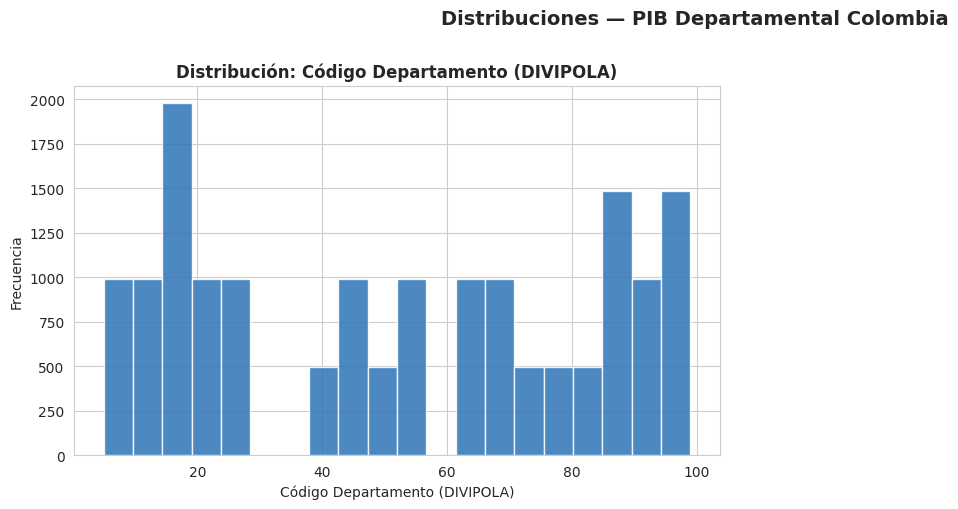

In [12]:
# Histogramas de todas las variables numéricas
numericas = df.select_dtypes(include='number')

if not numericas.empty:
    fig, axes = plt.subplots(nrows=(len(numericas.columns) + 1) // 2, ncols=2, figsize=(14, 5 * ((len(numericas.columns) + 1) // 2)))
    axes = axes.flatten()

    for i, col in enumerate(numericas.columns):
        axes[i].hist(numericas[col].dropna(), bins=20, color='#2E75B6', edgecolor='white', alpha=0.85)
        axes[i].set_title(f'Distribución: {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribuciones — PIB Departamental Colombia', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron variables numéricas para graficar.')

## 10. Correlaciones

In [14]:
# Matriz de correlación
numericas = df.select_dtypes(include='number')

if numericas.shape[1] >= 2:
    corr = numericas.corr()

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8}
    )
    plt.title('Matriz de Correlación — PIB Departamental', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

    print('\n📌 Observaciones sobre correlaciones:')
    print('  - Valores cercanos a 1 o -1 indican fuerte correlación.')
    print('  - Valores cercanos a 0 indican poca o ninguna correlación.')
else:
    print('Se necesitan al menos 2 variables numéricas para calcular correlaciones.')

Se necesitan al menos 2 variables numéricas para calcular correlaciones.


## 11. Reporte automático con Pandas Profiling (ydata-profiling)

In [15]:
# Generar reporte completo con ydata-profiling
print('⏳ Generando reporte de profiling... esto puede tomar unos segundos.')

profile = ProfileReport(
    df,
    title='Reporte de Exploración — PIB Departamental Colombia',
    explorative=True
)

# Mostrar en el notebook
profile.to_notebook_iframe()

⏳ Generando reporte de profiling... esto puede tomar unos segundos.


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 13.83it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
# Exportar el reporte como archivo HTML
profile.to_file('reporte_pib_departamental.html')
print('✅ Reporte guardado como: reporte_pib_departamental.html')

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Reporte guardado como: reporte_pib_departamental.html
